In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
iris = sns.load_dataset('iris')
print(iris.head())
print(type(iris), type(iris.values[0]))
print(iris.shape)
print(iris.columns)
print(iris.index)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.core.frame.DataFrame'> <class 'numpy.ndarray'>
(150, 5)
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
RangeIndex(start=0, stop=150, step=1)


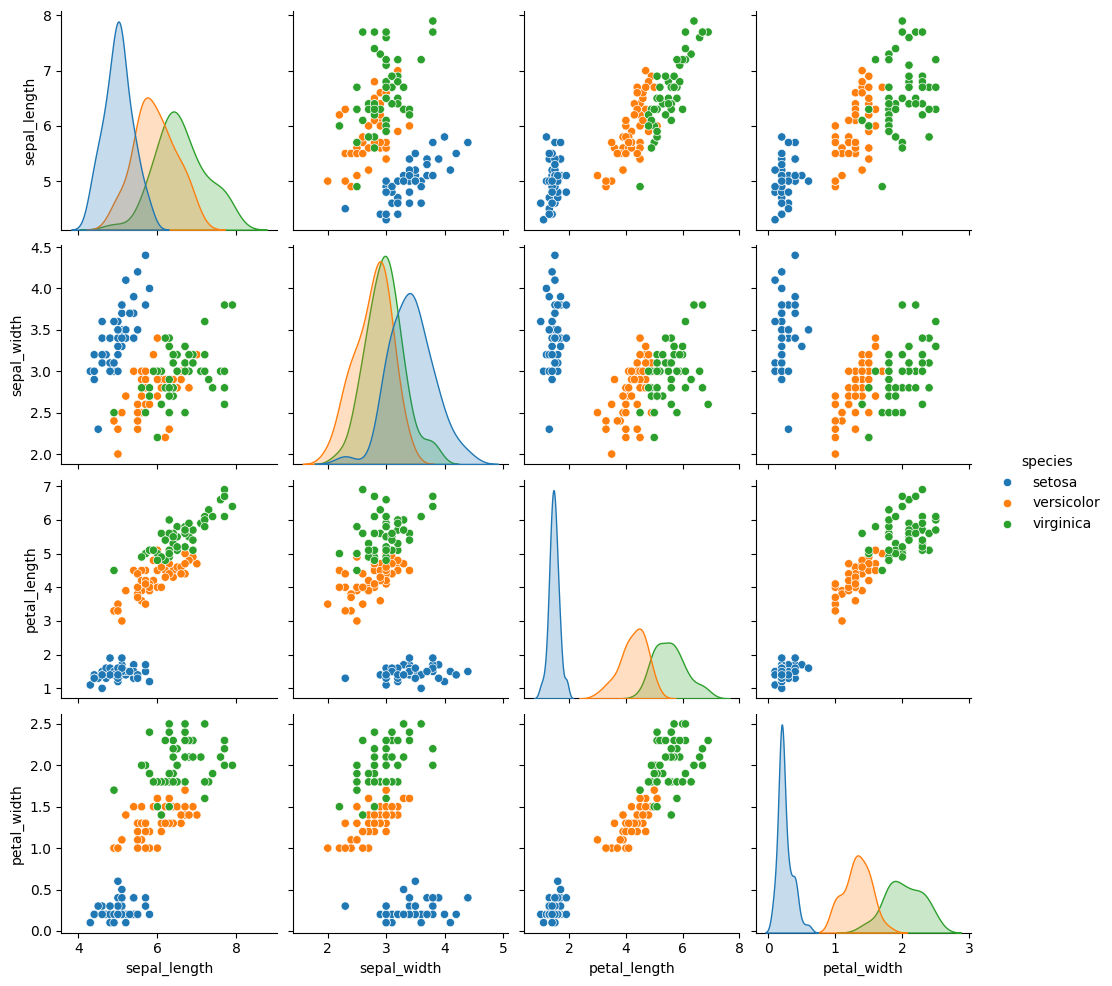

In [5]:
sns.pairplot(iris, hue='species')

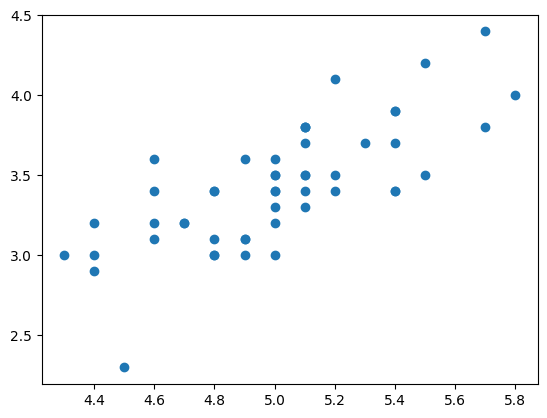

In [6]:
X_iris = iris.drop('species', axis=1)
y_iris = iris['species']

x = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()

plt.scatter(x, y)

In [7]:
model = LinearRegression()

predictor = model.fit(x[:, np.newaxis], y)

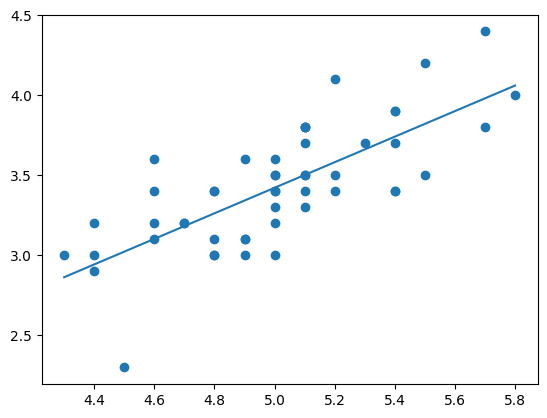

In [8]:
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = model.predict(x_fit[:, None])

plt.scatter(x, y)
plt.plot(x_fit, y_fit)

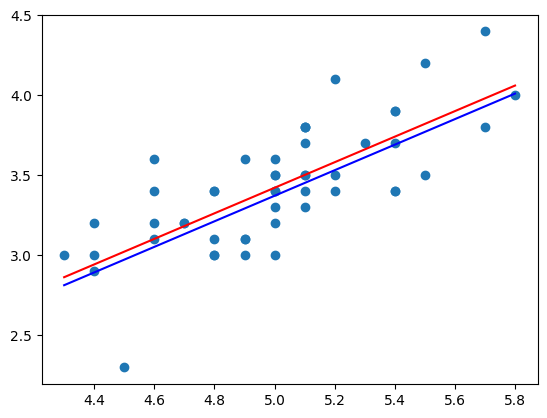

In [9]:

plt.scatter(x, y)
plt.plot(x_fit, x_fit * predictor.coef_ + predictor.intercept_ - 0.05, 'b')
plt.plot(x_fit, y_fit, 'r')

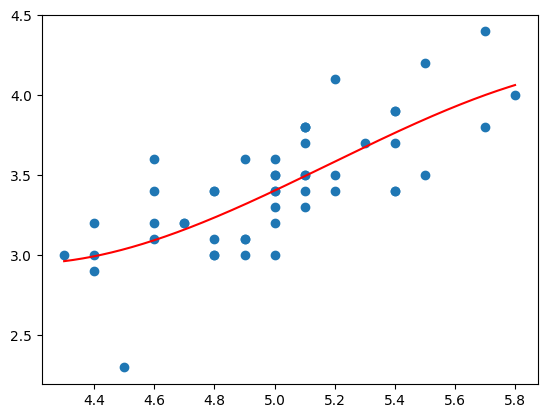

In [10]:
model = make_pipeline(PolynomialFeatures(3), LinearRegression())
predictor = model.fit(x[:, np.newaxis], y)

x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = model.predict(x_fit[:, None])

plt.scatter(x, y)
plt.plot(x_fit, y_fit, 'r')

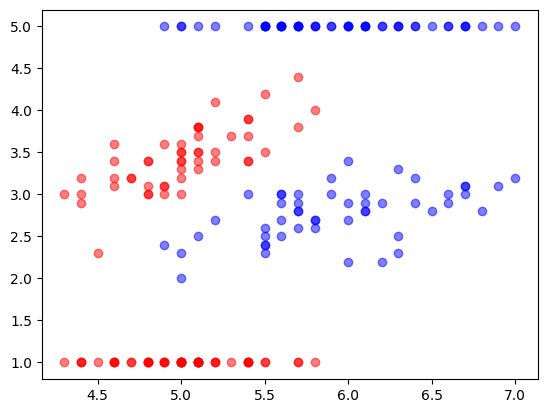

In [14]:
x_0 = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y_0 = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()

x_1 = iris[iris['species'] == 'versicolor'].iloc[:, 0].to_numpy()
y_1 = iris[iris['species'] == 'versicolor'].iloc[:, 1].to_numpy()

plt.scatter(x_0, y_0, color='red', alpha=0.5)
plt.scatter(x_1, y_1, color='blue', alpha=0.5)

plt.scatter(x_0, np.full(50, 1), color='red', alpha=0.5)
plt.scatter(x_1, np.full(50, 5), color='blue', alpha=0.5)

In [17]:
y = iris[iris['species'] != 'virginica'].iloc[:, 4]

model = LogisticRegression()
predictor = model.fit(np.concatenate([x_0, x_1])[:, None], y)

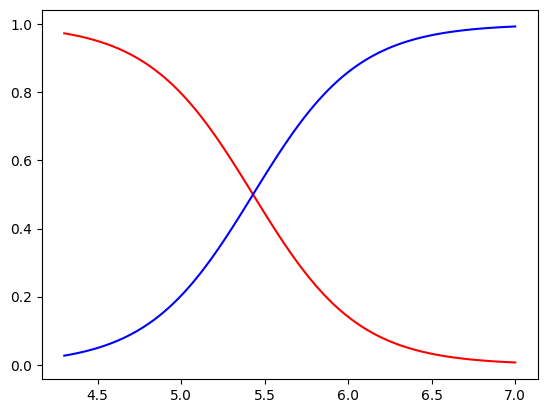

In [19]:
x_fit = np.linspace(x_0.min(), x_1.max(), 100)
y_fit = model.predict_proba(x_fit[:, None])
plt.plot(x_fit, y_fit[:, 0], 'r')
plt.plot(x_fit, y_fit[:, 1], 'b')

In [21]:
x = iris.iloc[:, :4]
y = iris.iloc[:, 4]

tree = DecisionTreeClassifier()
predtree = tree.fit(x, y)

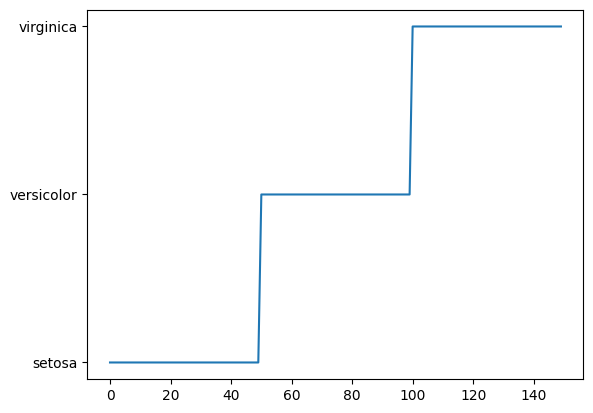

In [23]:
x_fit = x
y_fit = tree.predict(x_fit)

plt.plot([i for i in range(len(x_fit))], y_fit)